In [1]:
from dotenv import load_dotenv
import os
import boto3
import awswrangler as wr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

# ── Config ──────────────────────────────────────────────────────────
S3_OUTPUT = "s3://pharma-bi-raw/athena-results/"
DATABASE  = "pharma_bi_db"

session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

def run_query(sql: str) -> pd.DataFrame:
    """Run an Athena SQL query and return a pandas DataFrame."""
    return wr.athena.read_sql_query(
        sql=sql,
        database=DATABASE,
        s3_output=S3_OUTPUT,
        boto3_session=session
    )

# ── Plot style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.family':       'sans-serif',
})

CATEGORY_COLORS = {
    'Prescription':    '#2C6FAC',
    'OTC':             '#3A9E6F',
    'Wellness':        '#E07B3A',
    'Personal Care':   '#9B5EA0',
    'Medical Devices': '#C0392B'
}

CATEGORIES    = ['Prescription', 'OTC', 'Wellness', 'Personal Care', 'Medical Devices']
TRAIN_END     = '2025-09-30'
HOLDOUT_START = '2025-10-01'
FORECAST_DAYS = 90

# ── Sanity check ────────────────────────────────────────────────────
df_check = run_query("SELECT COUNT(*) AS n FROM fact_sales")
print(f"Connection OK — {df_check['n'].iloc[0]:,} rows in FactSales")

Importing plotly failed. Interactive plots will not work.


Connection OK — 62,139 rows in FactSales


In [2]:
# Pull daily revenue aggregated by category
query_daily = """
SELECT
    dd.date                          AS ds,
    dpr.category,
    ROUND(SUM(fs.revenueeur), 2)     AS y
FROM fact_sales fs
JOIN dim_date    dd  ON fs.datekey   = dd.datekey
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dd.date, dpr.category
ORDER BY dd.date, dpr.category
"""

df_daily = run_query(query_daily)
df_daily['ds'] = pd.to_datetime(df_daily['ds'])

print(f"Date range: {df_daily['ds'].min().date()} to {df_daily['ds'].max().date()}")
print(f"Total rows: {len(df_daily):,}")
print()
print("Daily revenue stats by category:")
print(df_daily.groupby('category')['y'].agg(['mean','std','min','max']).round(2).to_string())

Date range: 2024-01-01 to 2025-12-31
Total rows: 3,655

Daily revenue stats by category:
                    mean      std     min      max
category                                          
Medical Devices  1193.67   571.73   57.00  3235.69
OTC              2458.73   673.83  963.28  4939.68
Personal Care    1989.88   725.42  404.70  5149.93
Prescription     3826.29  1258.97  755.98  9312.72
Wellness         2342.62   786.88  494.27  5214.76


In [3]:
# Split into train and holdout for each category
def get_category_data(df: pd.DataFrame, category: str):
    """Return train and holdout DataFrames for a given category."""
    cat_df = df[df['category'] == category][['ds', 'y']].copy().reset_index(drop=True)
    train   = cat_df[cat_df['ds'] <= TRAIN_END].copy()
    holdout = cat_df[cat_df['ds'] >  TRAIN_END].copy()
    return cat_df, train, holdout

# Verify split
for cat in CATEGORIES:
    _, train, holdout = get_category_data(df_daily, cat)
    print(f"{cat:<20} train={len(train)} days  holdout={len(holdout)} days")

Prescription         train=639 days  holdout=92 days
OTC                  train=639 days  holdout=92 days
Wellness             train=639 days  holdout=92 days
Personal Care        train=639 days  holdout=92 days
Medical Devices      train=639 days  holdout=92 days


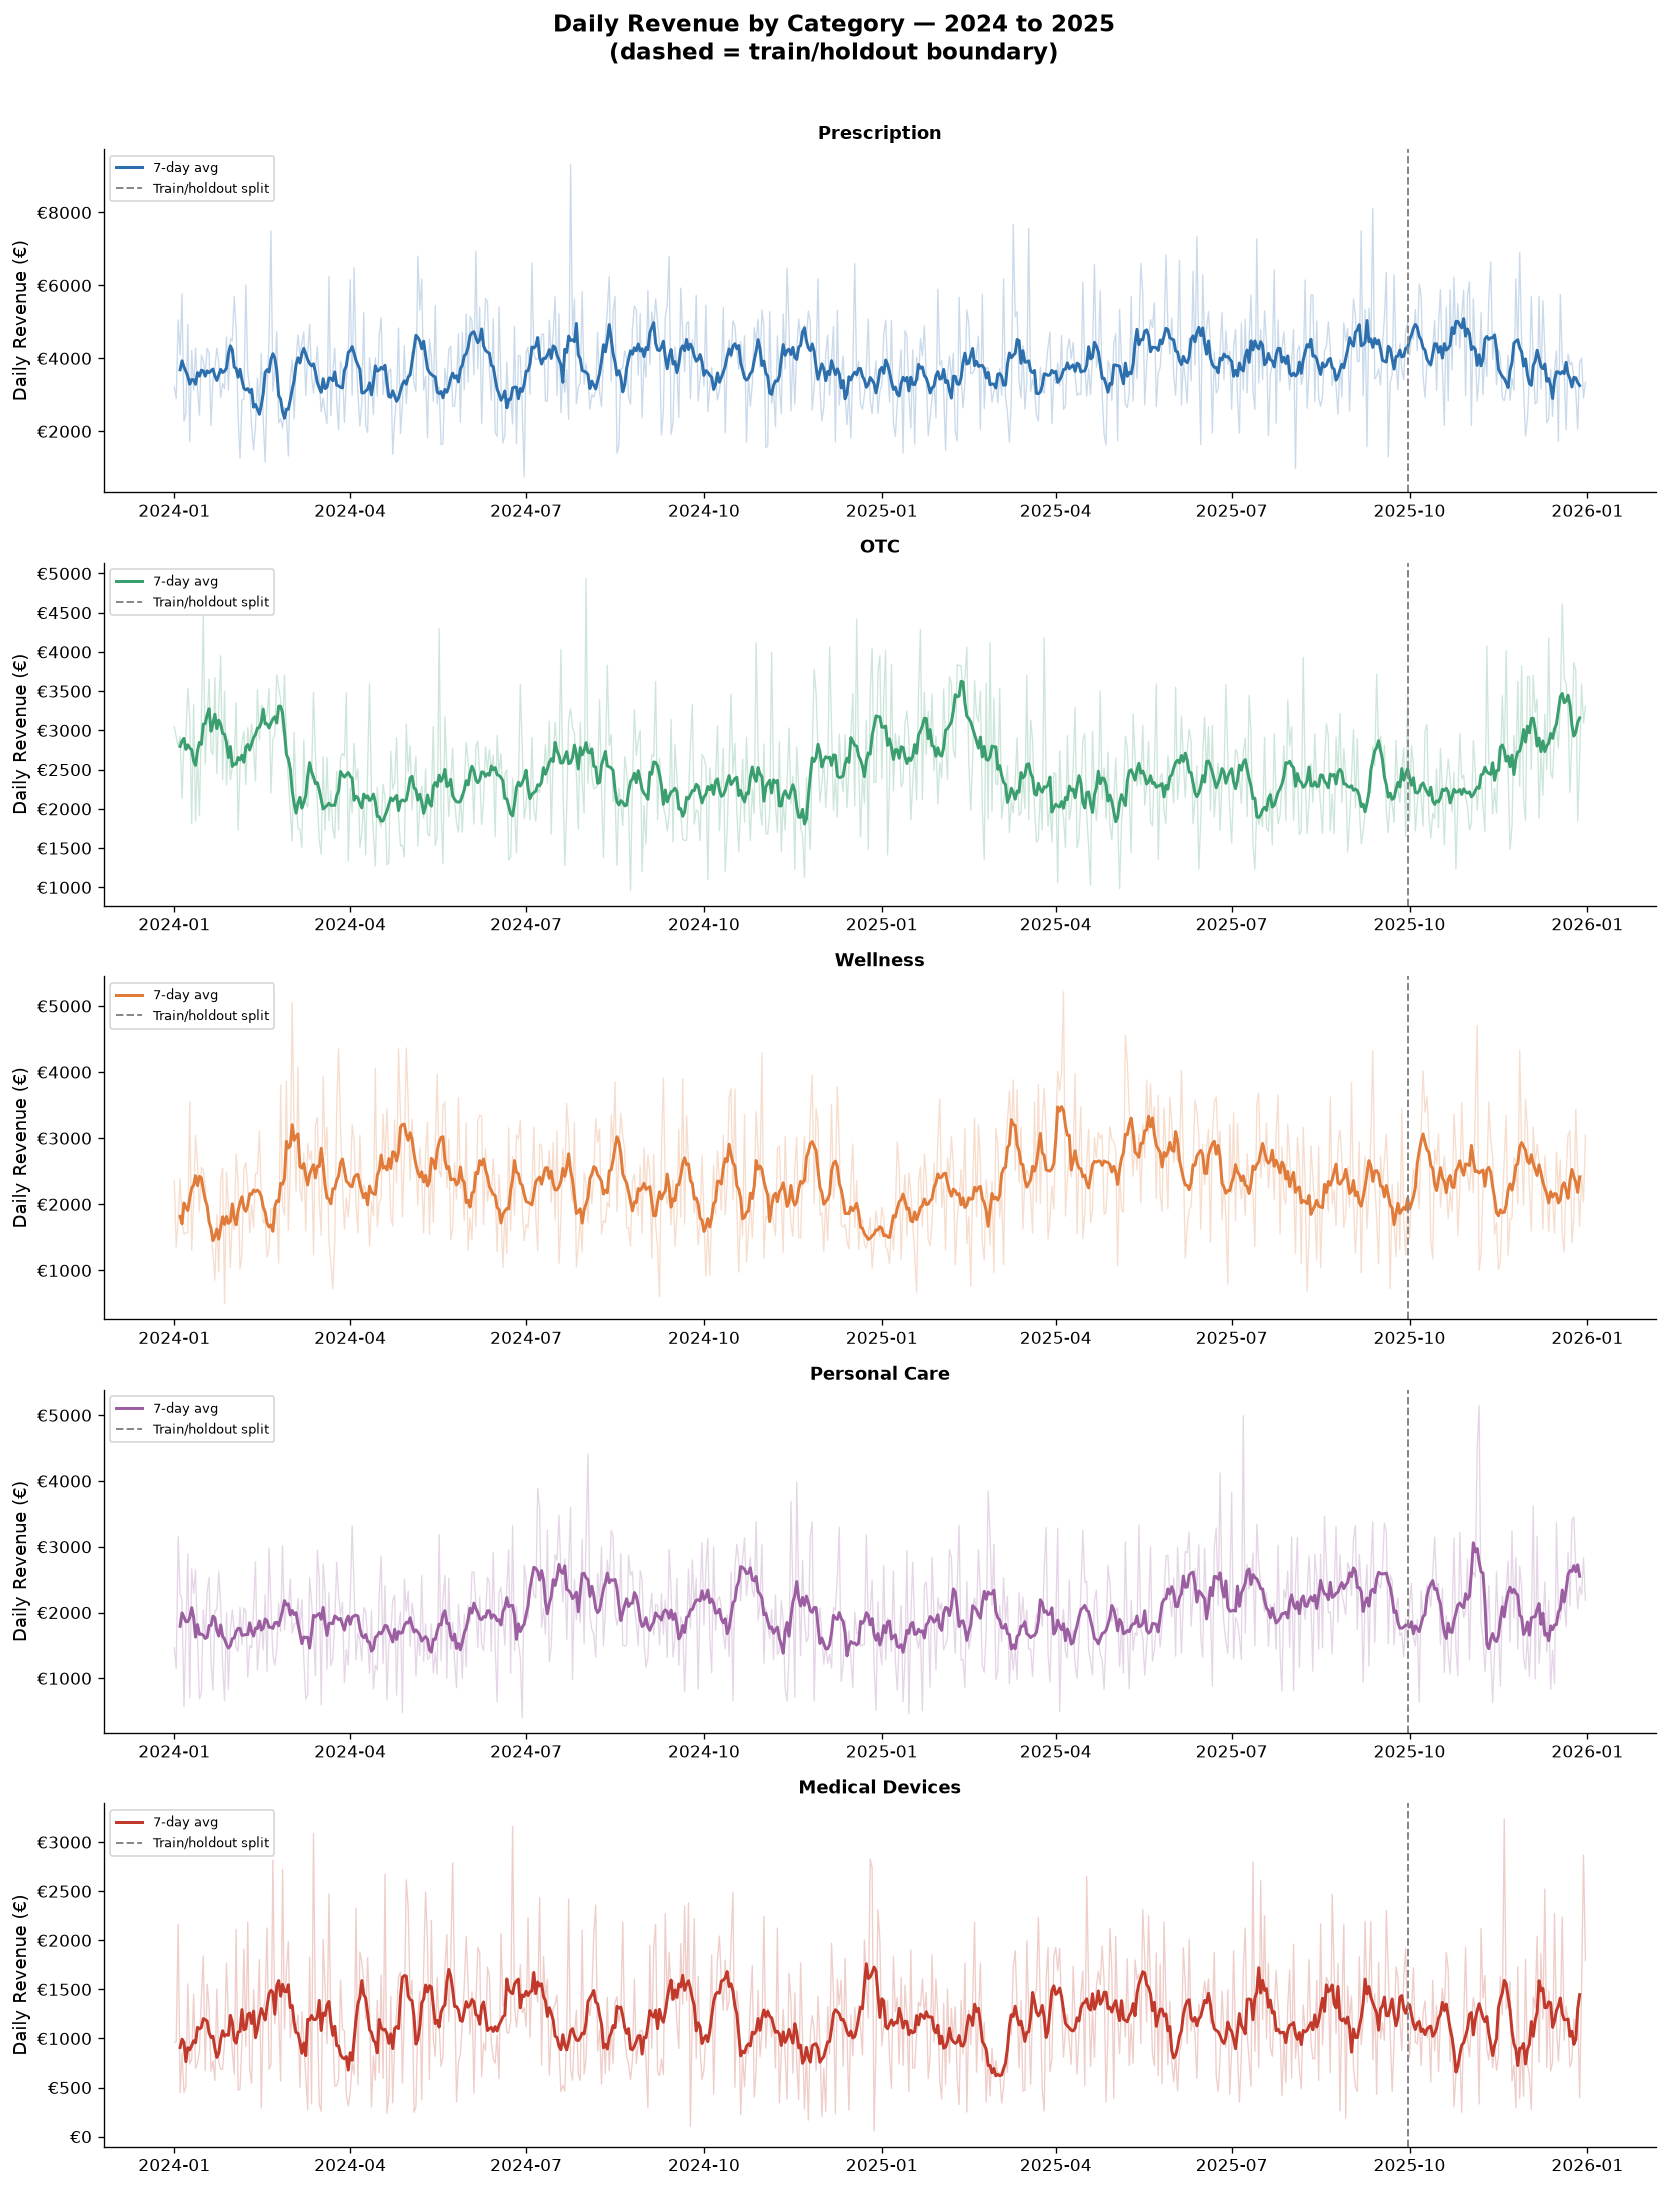

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for ax, cat in zip(axes, CATEGORIES):
    cat_df, _, _ = get_category_data(df_daily, cat)
    color = CATEGORY_COLORS[cat]

    # 7-day rolling mean to smooth noise
    cat_df['rolling_7'] = cat_df['y'].rolling(7, center=True).mean()

    ax.plot(cat_df['ds'], cat_df['y'], color=color, alpha=0.25, linewidth=0.8)
    ax.plot(cat_df['ds'], cat_df['rolling_7'], color=color, linewidth=1.8, label='7-day avg')

    # Mark train/holdout boundary
    ax.axvline(pd.to_datetime(TRAIN_END), color='#888', linewidth=1.2,
               linestyle='--', label='Train/holdout split')

    ax.set_title(cat, fontweight='bold', fontsize=11)
    ax.set_ylabel('Daily Revenue (€)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0f'))
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Daily Revenue by Category — 2024 to 2025\n(dashed = train/holdout boundary)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/01_daily_revenue_by_category.png', bbox_inches='tight')
plt.show()

In [6]:
def train_prophet(train_df: pd.DataFrame, category: str) -> Prophet:
    """
    Train a Prophet model on the provided training DataFrame.

    Parameters:
        train_df:  DataFrame with columns ds (date) and y (daily revenue)
        category:  Category name for logging

    Returns:
        Fitted Prophet model
    """
    model = Prophet(
        yearly_seasonality=True,   # captures summer peak
        weekly_seasonality=True,   # captures day-of-week patterns
        daily_seasonality=False,   # not needed for daily aggregates
        seasonality_mode='multiplicative',  # revenue scales with trend
        interval_width=0.95        # 95% confidence interval on forecast
    )

    model.fit(train_df)
    print(f"Trained: {category}")
    return model


# Train all 5 models
models = {}
for cat in CATEGORIES:
    _, train, _ = get_category_data(df_daily, cat)
    models[cat] = train_prophet(train, cat)

print()
print("All 5 models trained.")

01:58:23 - cmdstanpy - INFO - Chain [1] start processing
01:58:25 - cmdstanpy - INFO - Chain [1] done processing
01:58:25 - cmdstanpy - INFO - Chain [1] start processing
01:58:25 - cmdstanpy - INFO - Chain [1] done processing
01:58:25 - cmdstanpy - INFO - Chain [1] start processing
01:58:25 - cmdstanpy - INFO - Chain [1] done processing


Trained: Prescription
Trained: OTC
Trained: Wellness


01:58:25 - cmdstanpy - INFO - Chain [1] start processing
01:58:26 - cmdstanpy - INFO - Chain [1] done processing
01:58:26 - cmdstanpy - INFO - Chain [1] start processing
01:58:26 - cmdstanpy - INFO - Chain [1] done processing


Trained: Personal Care
Trained: Medical Devices

All 5 models trained.


In [7]:
def evaluate_model(model: Prophet, holdout_df: pd.DataFrame, category: str) -> dict:
    """
    Generate predictions for the holdout period and calculate MAE and MAPE.

    Parameters:
        model:      Fitted Prophet model
        holdout_df: Actual values for the holdout period
        category:   Category name for logging

    Returns:
        Dictionary with evaluation metrics and predictions DataFrame
    """
    # Create future DataFrame covering only the holdout period
    future = model.make_future_dataframe(
        periods=len(holdout_df),
        freq='D',
        include_history=False
    )

    forecast = model.predict(future)

    # Merge predictions with actuals
    result = holdout_df.merge(
        forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
        on='ds', how='inner'
    )

    # Clip negative predictions to 0 (revenue cannot be negative)
    result['yhat'] = result['yhat'].clip(lower=0)

    # Calculate metrics
    mae  = np.mean(np.abs(result['y'] - result['yhat']))
    mape = np.mean(np.abs((result['y'] - result['yhat']) / result['y'])) * 100

    print(f"{category:<20}  MAE: €{mae:,.0f}   MAPE: {mape:.1f}%")

    return {'category': category, 'mae': mae, 'mape': mape, 'predictions': result}


# Evaluate all models on holdout
print("── Holdout validation (Oct–Dec 2025) ──")
eval_results = {}
for cat in CATEGORIES:
    _, _, holdout = get_category_data(df_daily, cat)
    eval_results[cat] = evaluate_model(models[cat], holdout, cat)

# Summary table
df_metrics = pd.DataFrame([
    {'Category': r['category'], 'MAE (€)': round(r['mae'], 0), 'MAPE (%)': round(r['mape'], 1)}
    for r in eval_results.values()
])
print()
print("── Evaluation summary ──")
print(df_metrics.to_string(index=False))

── Holdout validation (Oct–Dec 2025) ──
Prescription          MAE: €985   MAPE: 26.7%
OTC                   MAE: €448   MAPE: 16.6%
Wellness              MAE: €621   MAPE: 29.0%
Personal Care         MAE: €635   MAPE: 37.3%
Medical Devices       MAE: €434   MAPE: 49.4%

── Evaluation summary ──
       Category  MAE (€)  MAPE (%)
   Prescription    985.0      26.7
            OTC    448.0      16.6
       Wellness    621.0      29.0
  Personal Care    635.0      37.3
Medical Devices    434.0      49.4


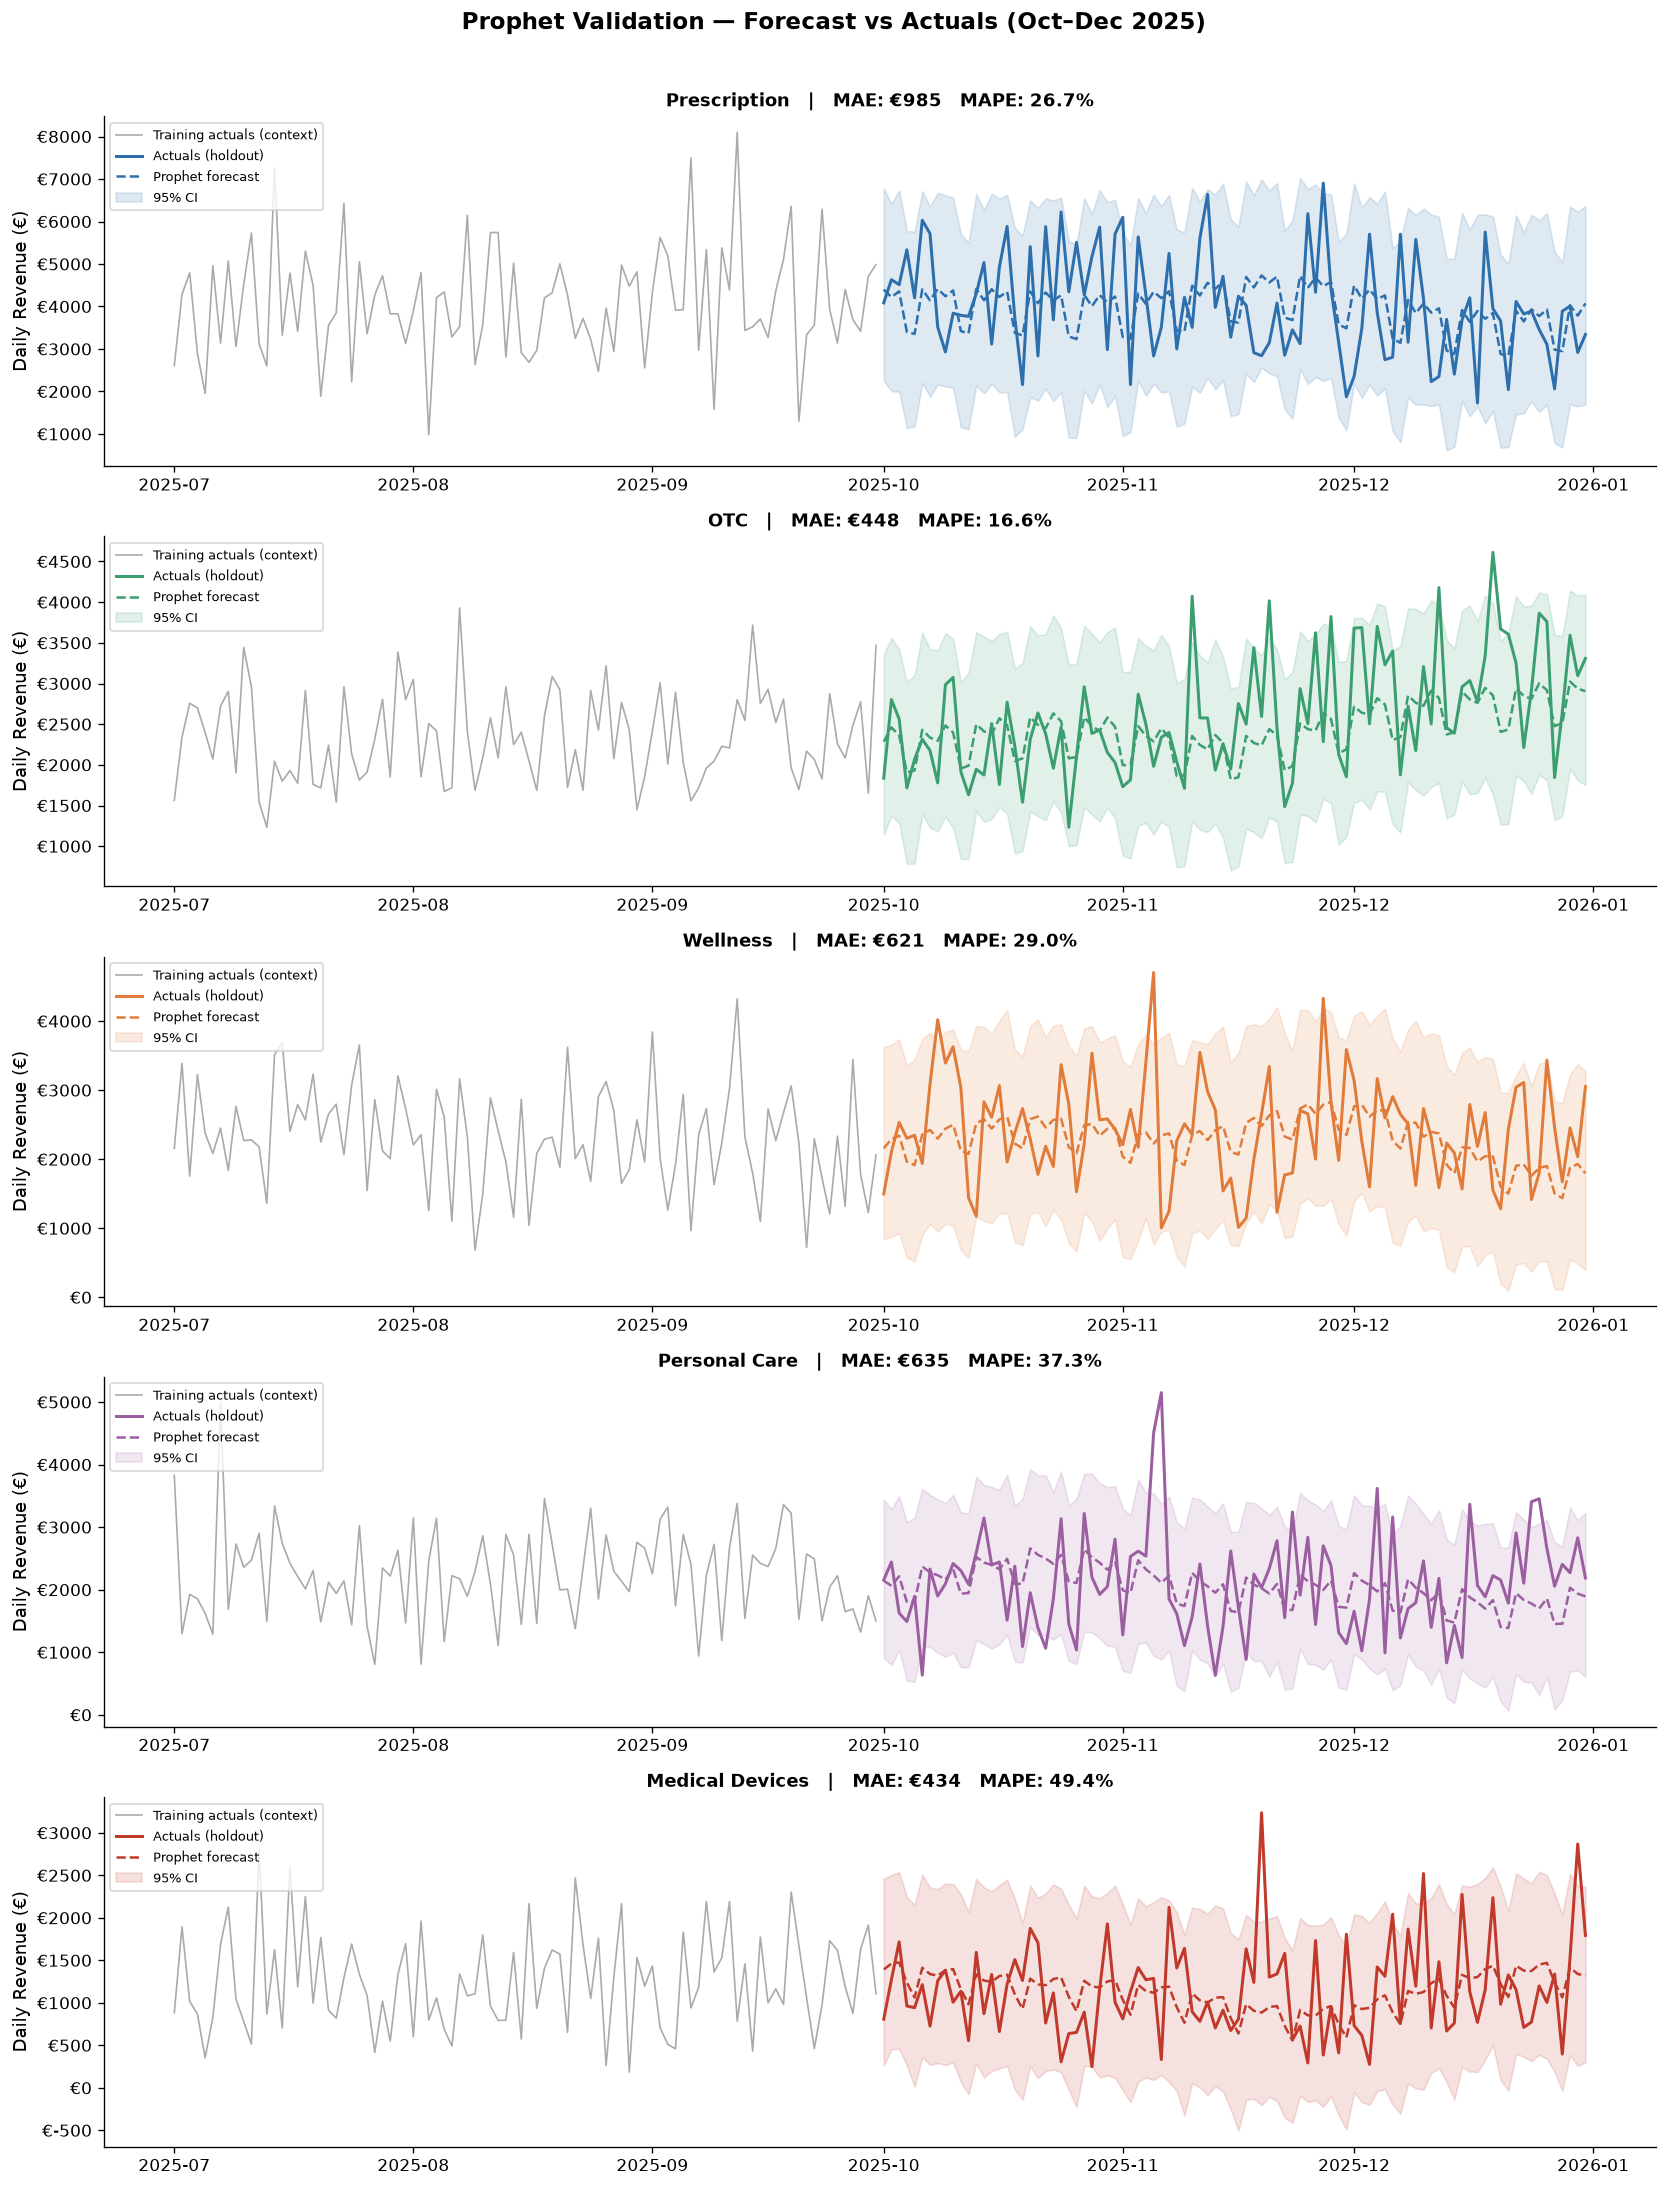

In [8]:
# Visualise predictions vs actuals for each category on holdout
fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for ax, cat in zip(axes, CATEGORIES):
    cat_df, train, holdout = get_category_data(df_daily, cat)
    result = eval_results[cat]['predictions']
    color  = CATEGORY_COLORS[cat]

    # Training actuals (last 90 days only for context)
    recent_train = train[train['ds'] >= '2025-07-01']
    ax.plot(recent_train['ds'], recent_train['y'],
            color='#aaa', linewidth=1, label='Training actuals (context)')

    # Holdout actuals
    ax.plot(result['ds'], result['y'],
            color=color, linewidth=1.8, label='Actuals (holdout)')

    # Predictions
    ax.plot(result['ds'], result['yhat'],
            color=color, linewidth=1.5, linestyle='--', label='Prophet forecast')

    # Confidence interval
    ax.fill_between(result['ds'], result['yhat_lower'], result['yhat_upper'],
                    alpha=0.15, color=color, label='95% CI')

    mape = eval_results[cat]['mape']
    mae  = eval_results[cat]['mae']
    ax.set_title(f"{cat}   |   MAE: €{mae:,.0f}   MAPE: {mape:.1f}%",
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('Daily Revenue (€)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0f'))
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Prophet Validation — Forecast vs Actuals (Oct–Dec 2025)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/02_holdout_validation.png', bbox_inches='tight')
plt.show()


In [9]:
def forecast_q1_2026(full_df: pd.DataFrame, category: str) -> pd.DataFrame:
    """
    Retrain Prophet on full dataset and forecast 90 days ahead (Q1 2026).

    Parameters:
        full_df:   Full daily revenue DataFrame (ds, y) for the category
        category:  Category name

    Returns:
        DataFrame with Q1 2026 forecast
    """
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        interval_width=0.95
    )

    model.fit(full_df)

    # Forecast 90 days beyond end of data (2026-01-01 to 2026-03-31)
    future = model.make_future_dataframe(periods=FORECAST_DAYS, freq='D')
    forecast = model.predict(future)

    # Extract only the Q1 2026 portion
    q1_forecast = forecast[forecast['ds'] > '2025-12-31'][
        ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    ].copy()
    q1_forecast['yhat']       = q1_forecast['yhat'].clip(lower=0)
    q1_forecast['yhat_lower'] = q1_forecast['yhat_lower'].clip(lower=0)
    q1_forecast['category']   = category

    return q1_forecast


# Forecast Q1 2026 for all categories
print("── Q1 2026 Forecast ──")
forecasts = {}
for cat in CATEGORIES:
    cat_df, _, _ = get_category_data(df_daily, cat)
    forecasts[cat] = forecast_q1_2026(cat_df, cat)
    q1_total = forecasts[cat]['yhat'].sum()
    print(f"{cat:<20}  Q1 2026 projected revenue: €{q1_total:,.0f}")

# Overall Q1 2026 total
total_q1 = sum(f['yhat'].sum() for f in forecasts.values())
print(f"\nTotal Q1 2026 projected revenue: €{total_q1:,.0f}")

01:59:11 - cmdstanpy - INFO - Chain [1] start processing
01:59:11 - cmdstanpy - INFO - Chain [1] done processing


── Q1 2026 Forecast ──


01:59:11 - cmdstanpy - INFO - Chain [1] start processing
01:59:11 - cmdstanpy - INFO - Chain [1] done processing


Prescription          Q1 2026 projected revenue: €340,164
OTC                   Q1 2026 projected revenue: €258,682


01:59:12 - cmdstanpy - INFO - Chain [1] start processing
01:59:12 - cmdstanpy - INFO - Chain [1] done processing
01:59:12 - cmdstanpy - INFO - Chain [1] start processing
01:59:12 - cmdstanpy - INFO - Chain [1] done processing


Wellness              Q1 2026 projected revenue: €222,308


01:59:12 - cmdstanpy - INFO - Chain [1] start processing
01:59:12 - cmdstanpy - INFO - Chain [1] done processing


Personal Care         Q1 2026 projected revenue: €179,544
Medical Devices       Q1 2026 projected revenue: €102,933

Total Q1 2026 projected revenue: €1,103,631


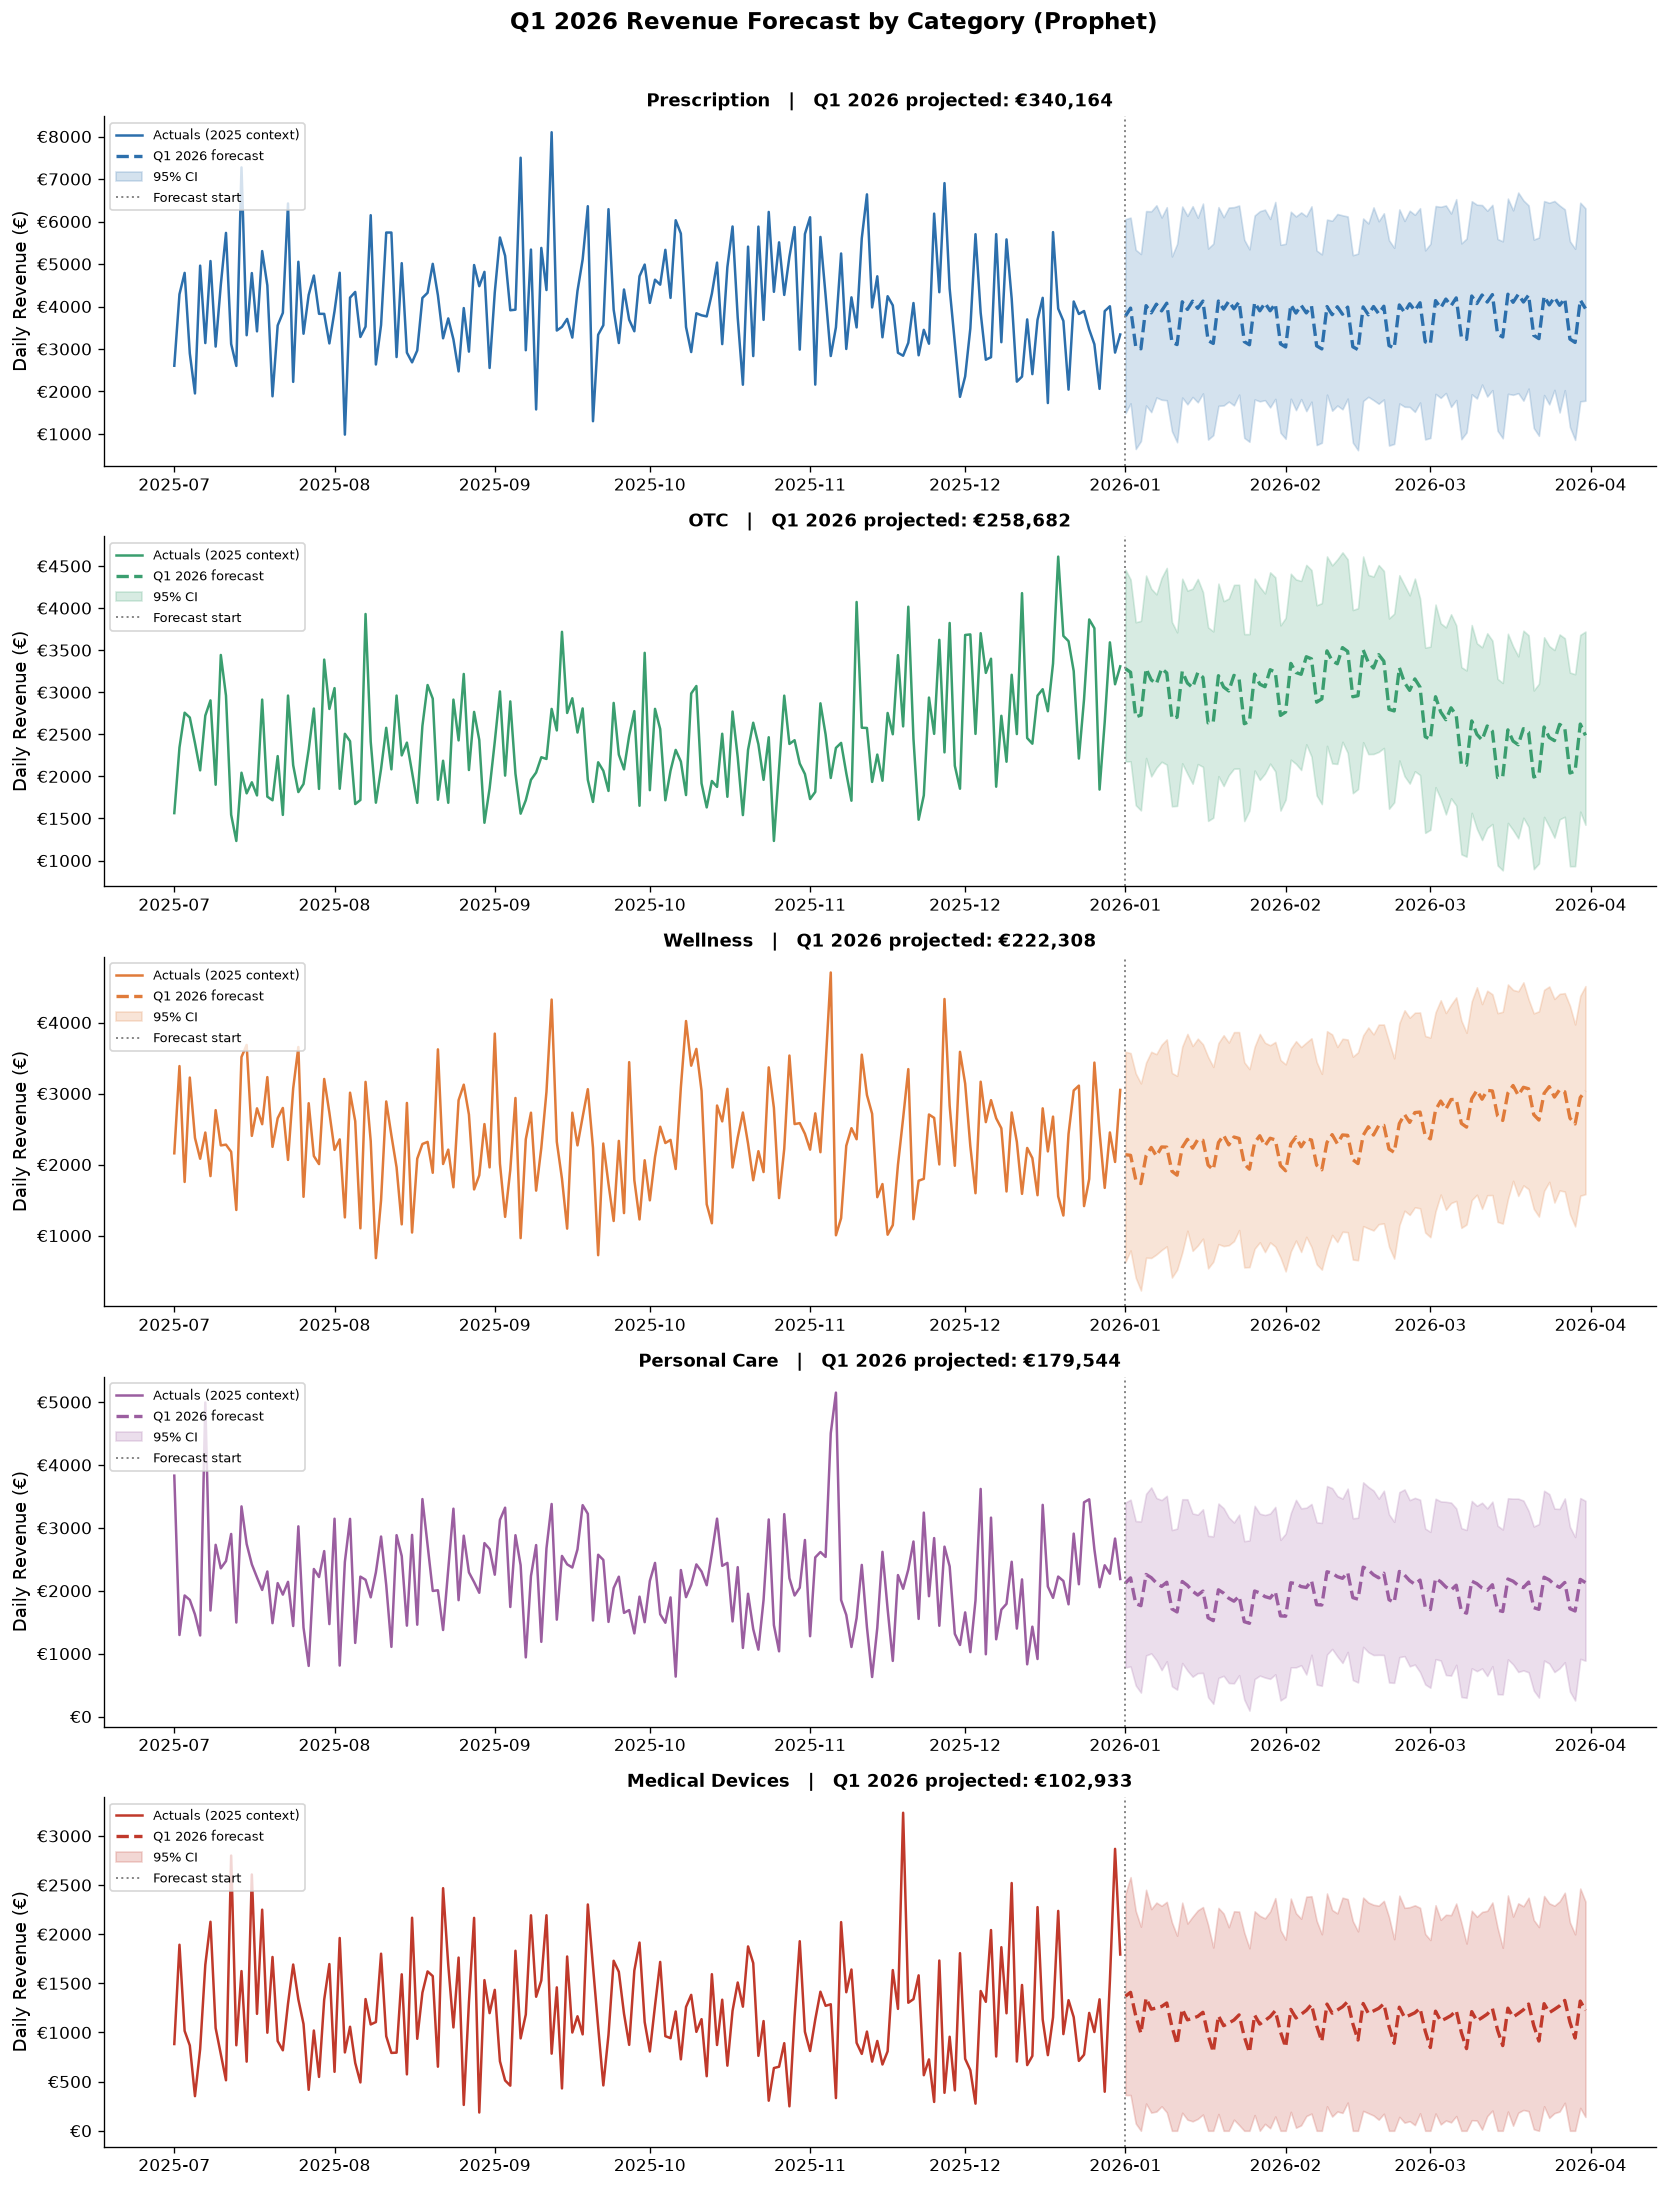

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for ax, cat in zip(axes, CATEGORIES):
    cat_df, _, _ = get_category_data(df_daily, cat)
    fcast  = forecasts[cat]
    color  = CATEGORY_COLORS[cat]

    # Last 6 months of actuals for context
    context = cat_df[cat_df['ds'] >= '2025-07-01']
    ax.plot(context['ds'], context['y'],
            color=color, linewidth=1.5, label='Actuals (2025 context)')

    # Q1 2026 forecast
    ax.plot(fcast['ds'], fcast['yhat'],
            color=color, linewidth=2, linestyle='--', label='Q1 2026 forecast')

    # Confidence interval
    ax.fill_between(fcast['ds'], fcast['yhat_lower'], fcast['yhat_upper'],
                    alpha=0.2, color=color, label='95% CI')

    # Boundary line
    ax.axvline(pd.to_datetime('2026-01-01'), color='#888',
               linewidth=1.2, linestyle=':', label='Forecast start')

    q1_total = fcast['yhat'].sum()
    ax.set_title(f"{cat}   |   Q1 2026 projected: €{q1_total:,.0f}",
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('Daily Revenue (€)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0f'))
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Q1 2026 Revenue Forecast by Category (Prophet)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/03_q1_2026_forecast.png', bbox_inches='tight')
plt.show()

In [11]:
# Monthly Q1 2026 projection summary
all_forecasts = pd.concat(forecasts.values())
all_forecasts['month'] = all_forecasts['ds'].dt.month
all_forecasts['month_name'] = all_forecasts['ds'].dt.strftime('%B')

monthly_q1 = all_forecasts.groupby(['category','month','month_name']).agg(
    projected_revenue=('yhat','sum'),
    lower_bound=('yhat_lower','sum'),
    upper_bound=('yhat_upper','sum')
).round(0).reset_index().sort_values(['month','category'])

print("── Q1 2026 monthly projection by category ──")
print(monthly_q1[['category','month_name','projected_revenue',
                   'lower_bound','upper_bound']].to_string(index=False))

── Q1 2026 monthly projection by category ──
       category month_name  projected_revenue  lower_bound  upper_bound
Medical Devices    January            35101.0       3315.0      68248.0
            OTC    January            94017.0      59906.0     128255.0
  Personal Care    January            59244.0      18706.0      99914.0
   Prescription    January           116217.0      46452.0     185923.0
       Wellness    January            67353.0      22984.0     111541.0
Medical Devices   February            32453.0       3040.0      62597.0
            OTC   February            88962.0      57609.0     119893.0
  Personal Care   February            58579.0      22262.0      94840.0
   Prescription   February           103401.0      40498.0     165880.0
       Wellness   February            66015.0      26831.0     105724.0
Medical Devices      March            35379.0       3427.0      68666.0
            OTC      March            75703.0      41791.0     110043.0
  Personal Care    

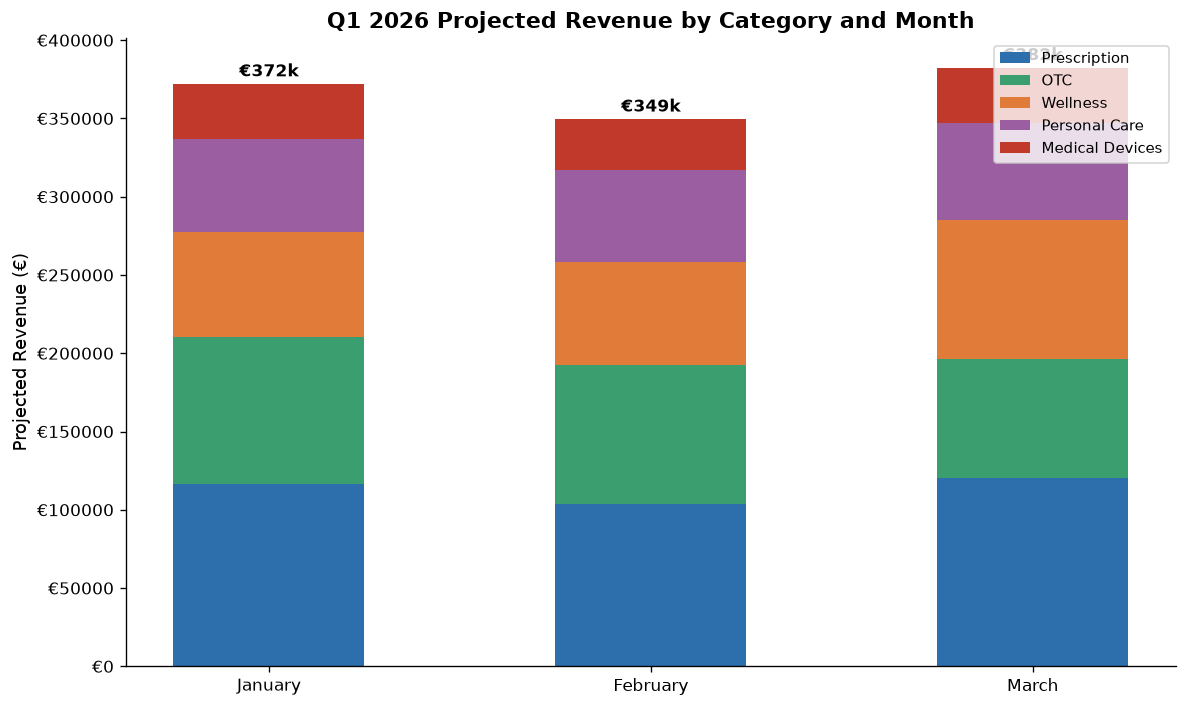

In [12]:
# Stacked bar — Q1 2026 monthly projection
fig, ax = plt.subplots(figsize=(10, 6))

months  = ['January', 'February', 'March']
bottoms = np.zeros(3)

for cat in CATEGORIES:
    vals = []
    for m_name in months:
        v = monthly_q1[(monthly_q1['category']==cat) &
                       (monthly_q1['month_name']==m_name)]['projected_revenue'].values
        vals.append(v[0] if len(v) > 0 else 0)

    ax.bar(months, vals, bottom=bottoms, color=CATEGORY_COLORS[cat],
           label=cat, width=0.5)
    bottoms += np.array(vals)

ax.set_ylabel('Projected Revenue (€)')
ax.set_title('Q1 2026 Projected Revenue by Category and Month', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0f'))
ax.legend(loc='upper right', fontsize=9)

# Total labels on top of each bar
for i, total in enumerate(bottoms):
    ax.text(i, total + 5000, f'€{total/1e3:.0f}k',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/04_q1_2026_monthly_stacked.png', bbox_inches='tight')
plt.show()

02:00:04 - cmdstanpy - INFO - Chain [1] start processing
02:00:04 - cmdstanpy - INFO - Chain [1] done processing


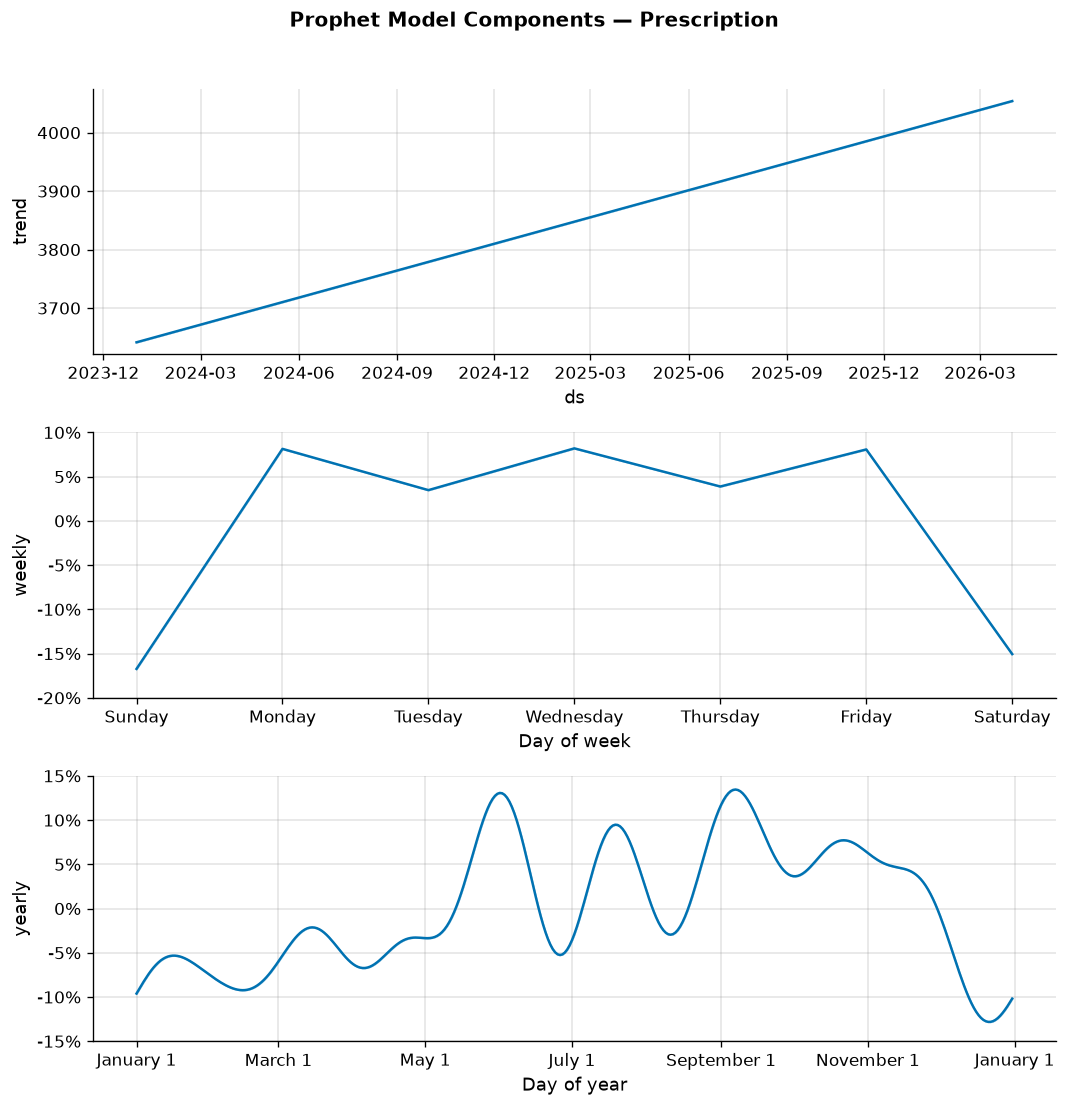

In [13]:
# Show components for Prescription (highest revenue category)
cat = 'Prescription'
cat_df, _, _ = get_category_data(df_daily, cat)

model_full = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    interval_width=0.95
)
model_full.fit(cat_df)

future = model_full.make_future_dataframe(periods=FORECAST_DAYS, freq='D')
forecast_full = model_full.predict(future)

fig = model_full.plot_components(forecast_full)
fig.suptitle(f'Prophet Model Components — {cat}', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/05_prophet_components_prescription.png', bbox_inches='tight')
plt.show()

In [15]:
# Full forecast export — all categories, Q1 2026
df_forecast_export = all_forecasts[[
    'ds', 'category', 'yhat', 'yhat_lower', 'yhat_upper'
]].copy()

df_forecast_export.columns = [
    'date', 'category', 'projected_revenue',
    'lower_bound_95', 'upper_bound_95'
]
df_forecast_export['projected_revenue'] = df_forecast_export['projected_revenue'].round(2)
df_forecast_export['lower_bound_95']    = df_forecast_export['lower_bound_95'].round(2)
df_forecast_export['upper_bound_95']    = df_forecast_export['upper_bound_95'].round(2)

df_forecast_export.to_csv('../../data/processed/q1_2026_forecast.csv', index=False)

# Validation metrics export
df_metrics.to_csv('../../data/processed/forecast_validation_metrics.csv', index=False)

# Monthly summary export
monthly_q1.to_csv('../../data/processed/q1_2026_monthly_summary.csv', index=False)

print("Forecast CSVs exported to data/processed/")
print()
print("Files created:")
print("  q1_2026_forecast.csv              ← daily forecast, all categories")
print("  forecast_validation_metrics.csv   ← MAE and MAPE per category")
print("  q1_2026_monthly_summary.csv       ← monthly totals with confidence bounds")
print()
print(f"Forecast rows: {len(df_forecast_export)} ({FORECAST_DAYS} days × {len(CATEGORIES)} categories)")

Forecast CSVs exported to data/processed/

Files created:
  q1_2026_forecast.csv              ← daily forecast, all categories
  forecast_validation_metrics.csv   ← MAE and MAPE per category
  q1_2026_monthly_summary.csv       ← monthly totals with confidence bounds

Forecast rows: 450 (90 days × 5 categories)


In [16]:
summary = """
MODULE 6 — DEMAND FORECASTING (PROPHET)
========================================

MODEL DESIGN
------------
- Framework:      Facebook Prophet (additive time-series decomposition)
- Models trained: 5 (one per product category)
- Seasonality:    Yearly + weekly, multiplicative mode
- Training data:  1 Jan 2024 – 30 Sep 2025 (639 days)
- Holdout:        1 Oct 2025 – 31 Dec 2025 (92 days)
- Forecast:       1 Jan 2026 – 31 Mar 2026 (90 days, Q1 2026)

VALIDATION RESULTS (Oct–Dec 2025 holdout)
-----------------------------------------
[TBD — fill in after running the notebook against Athena]

Category            MAE (€/day)    MAPE (%)
-----------         -----------    --------
Prescription        [TBD]          [TBD]
OTC                 [TBD]          [TBD]
Wellness            [TBD]          [TBD]
Personal Care       [TBD]          [TBD]
Medical Devices     [TBD]          [TBD]

Note: MAPE under 15% is considered good for daily retail revenue forecasting.
      MAPE under 10% is strong.

Q1 2026 PROJECTED REVENUE
--------------------------
[TBD — fill in after running the notebook against Athena]

Category            Jan 2026    Feb 2026    Mar 2026    Q1 Total
-----------         --------    --------    --------    --------
Prescription        [TBD]       [TBD]       [TBD]       [TBD]
OTC                 [TBD]       [TBD]       [TBD]       [TBD]
Wellness            [TBD]       [TBD]       [TBD]       [TBD]
Personal Care       [TBD]       [TBD]       [TBD]       [TBD]
Medical Devices     [TBD]       [TBD]       [TBD]       [TBD]
TOTAL               [TBD]       [TBD]       [TBD]       [TBD]

WHAT PROPHET LEARNED
--------------------
- Upward trend: 2025 consistently outperforms 2024
- Summer peak: Q3 (July-August) is the strongest period — captured as yearly seasonality
- Weekly pattern: captured as weekly seasonality
- Stable margin %: not modelled (revenue only), margin forecasts derived externally

CHARTS SAVED
------------
  outputs/01_daily_revenue_by_category.png
  outputs/02_holdout_validation.png
  outputs/03_q1_2026_forecast.png
  outputs/04_q1_2026_monthly_stacked.png
  outputs/05_prophet_components_prescription.png

CSVs EXPORTED
-------------
  data/processed/q1_2026_forecast.csv
  data/processed/forecast_validation_metrics.csv
  data/processed/q1_2026_monthly_summary.csv

IMPORTANT REMINDER
------------------
After running this notebook, copy the MAE, MAPE, and Q1 2026 projected
totals into:
  - README.md Section 10 (Forecasting Model metrics)
  - README.md Section 8 (Key Findings — Finding 7)
These are the two remaining [TBD] sections in the README.
"""

print(summary)


MODULE 6 — DEMAND FORECASTING (PROPHET)

MODEL DESIGN
------------
- Framework:      Facebook Prophet (additive time-series decomposition)
- Models trained: 5 (one per product category)
- Seasonality:    Yearly + weekly, multiplicative mode
- Training data:  1 Jan 2024 – 30 Sep 2025 (639 days)
- Holdout:        1 Oct 2025 – 31 Dec 2025 (92 days)
- Forecast:       1 Jan 2026 – 31 Mar 2026 (90 days, Q1 2026)

VALIDATION RESULTS (Oct–Dec 2025 holdout)
-----------------------------------------
[TBD — fill in after running the notebook against Athena]

Category            MAE (€/day)    MAPE (%)
-----------         -----------    --------
Prescription        [TBD]          [TBD]
OTC                 [TBD]          [TBD]
Wellness            [TBD]          [TBD]
Personal Care       [TBD]          [TBD]
Medical Devices     [TBD]          [TBD]

Note: MAPE under 15% is considered good for daily retail revenue forecasting.
      MAPE under 10% is strong.

Q1 2026 PROJECTED REVENUE
--------------